In [1]:
import pandas as pd

file_path = 'df_bal.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda
0,6212783,1359.0,2,35,52403,0,2,1,1,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.500000,0.000000,2
1,323327,51.0,2,14,308,0,2,1,1,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.333333,0.333333,0
2,2396561,551.0,2,26,4106,0,1,1,1,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.000000,1
3,2393737,480.0,2,26,11002,0,2,1,1,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.500000,0.000000,1
4,4941249,192.0,2,32,4559,0,6,1,1,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.400000,0.000000,0


In [2]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [3]:
df = df.drop(columns=['VL_RENDA_MEDIA_FAM'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 51 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ID_FAM_ANON                   999999 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      999999 non-null  int64  
 2   CO_MUNIC_IBGE_2_FAM           999999 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           999999 non-null  int64  
 4   IN_FORMULARIO_SUP2_FAM        999999 non-null  int64  
 5   QT_PESSOAS_DOMIC_FAM          999999 non-null  int64  
 6   QT_FAMILIAS_DOMIC_FAM         999999 non-null  int64  
 7   CO_ESPECIE_DOMIC_FAM          999999 non-null  int64  
 8   CO_LOCAL_DOMIC_FAM            999999 non-null  int64  
 9   QT_COMODOS_DOMIC_FAM          999999 non-null  int64  
 10  QT_COMODOS_DORMITORIO_FAM     999999 non-null  int64  
 11  CO_MATERIAL_DOMIC_FAM         999999 non-null  int64  
 12  CO_MATERIAL_PISO_FAM          999999 non-nul

In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [6]:
df['classe_renda'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 999999 entries, 0 to 999998
Series name: classe_renda
Non-Null Count   Dtype
--------------   -----
999999 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


In [7]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_TRABALHOU_SEMANA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_AGRICULTURA_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS'

## Análise de correlação das variáveis

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ---- 1) Listas das categorias ----

cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 'IN_FORMULARIO_SUP2_FAM',
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
    'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
    'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
    'CO_TRABALHO_12_MESES_MEMB',
]

bool_cols = [
    'TEM_CRIANCA_SEM_ESCOLA',
    'TEM_ADOLESCENTE_SEM_ESCOLA',
    ]

pct_cols = [
    'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
    'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
    'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
    'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
       'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
       'PCT_MENOR6_FORA_CRECHE_PRE', 
]


quant_cols = [
    'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
    'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
    'IDADE_REFERENCIA',
]

# Conjuntos auxiliares para testar tipo rapidamente
cat_all = cat_num_cols + bool_cols    # tratadas como categóricas
num_all = quant_cols + pct_cols                    # tratadas como numéricas

set_cat = set(cat_all)
set_num = set(num_all)

# Todas as variáveis consideradas
all_vars = cat_all + num_all

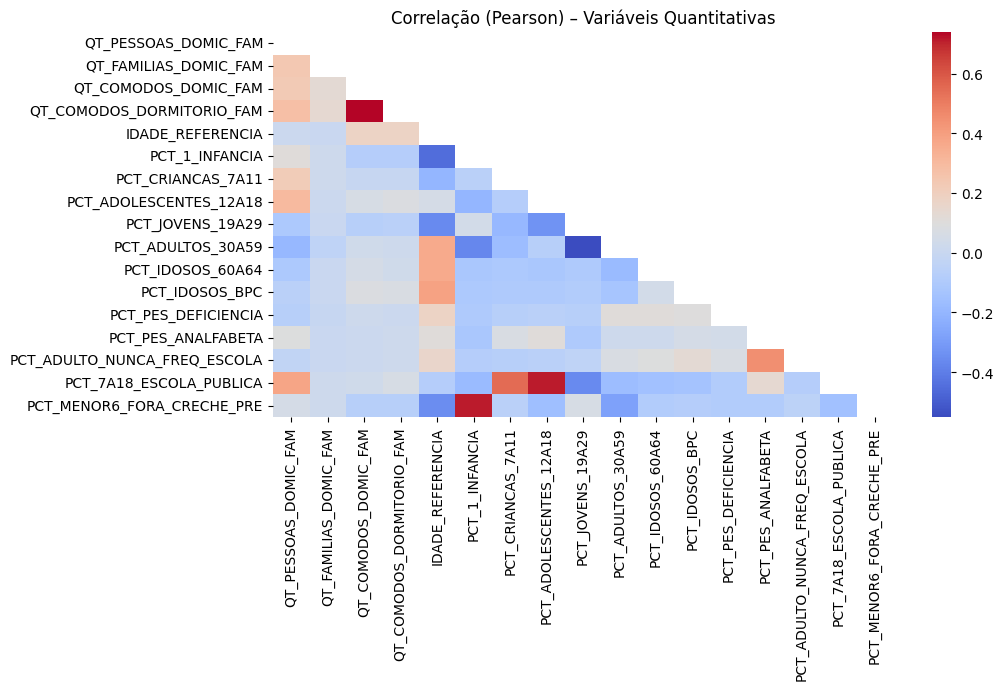

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas quantitativas
df_quant = df[quant_cols + pct_cols]

# Matriz de correlação Pearson
corr_quant = df_quant.corr(method='pearson')

# Máscara acima da diagonal
mask = np.triu(np.ones_like(corr_quant, dtype=bool))

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_quant.round(2),
    annot=False,
    cmap='coolwarm',
    mask=mask
)
plt.title("Correlação (Pearson) – Variáveis Quantitativas")
plt.show()


In [10]:
# Converter matriz para formato longo (var1, var2, corr)
corr_pairs = (
    corr_quant
        .where(np.triu(np.ones(corr_quant.shape), k=1).astype(bool))  # apenas acima da diagonal
        .stack()
        .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'corr']

# Ordenar pelas correlações mais fortes (em valor absoluto)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs['corr'].abs().sort_values(ascending=False).index)

# Mostrar top 20
corr_pairs_sorted.head(20)


,var1,var2,corr
31,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,0.742900
98,PCT_ADOLESCENTES_12A18,PCT_7A18_ESCOLA_PUBLICA,0.710755
80,PCT_1_INFANCIA,PCT_MENOR6_FORA_CRECHE_PRE,0.708793
100,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,-0.554701
89,PCT_CRIANCAS_7A11,PCT_7A18_ESCOLA_PUBLICA,0.546490
58,IDADE_REFERENCIA,PCT_1_INFANCIA,-0.454464
130,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,0.453739
64,IDADE_REFERENCIA,PCT_IDOSOS_BPC,0.388126
14,QT_PESSOAS_DOMIC_FAM,PCT_7A18_ESCOLA_PUBLICA,0.383576
73,PCT_1_INFANCIA,PCT_ADULTOS_30A59,-0.372720


In [11]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    if t.shape[0] <= 1 or t.shape[1] <= 1:
        return np.nan
    chi2, p, dof, expected = chi2_contingency(t)
    n = t.to_numpy().sum()
    r, k = t.shape
    return np.sqrt(chi2 / (n*(min(r,k)-1)))


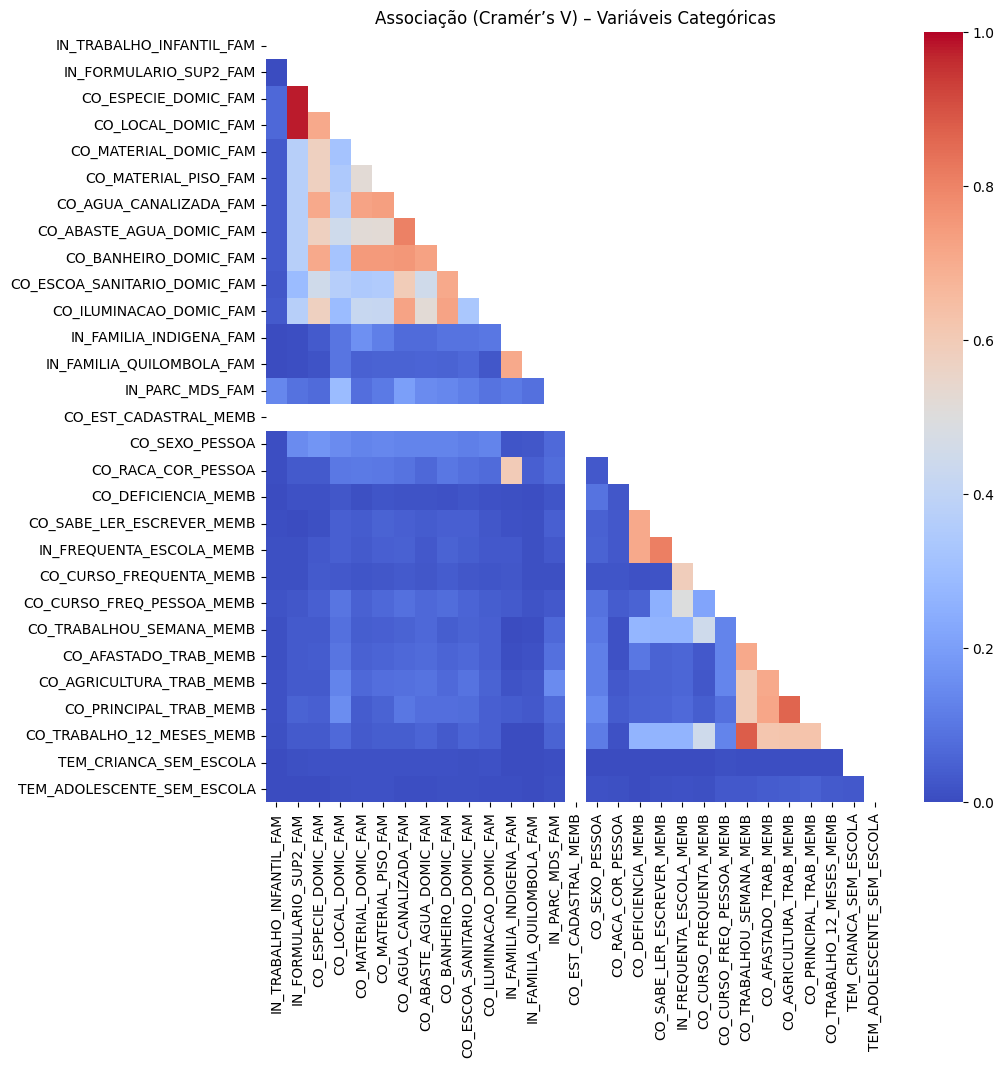

In [12]:
# Selecionar todas as categóricas
df_cat = df[cat_num_cols + bool_cols]

# Matriz vazia
cramers_mat = pd.DataFrame(index=df_cat.columns, columns=df_cat.columns)

# Preencher matriz
for c1 in df_cat.columns:
    for c2 in df_cat.columns:
        if c1 == c2:
            cramers_mat.loc[c1, c2] = 1
        else:
            cramers_mat.loc[c1, c2] = cramers_v(df_cat[c1], df_cat[c2])

# Converter para float
cramers_mat = cramers_mat.astype(float)

# Máscara
mask = np.triu(np.ones_like(cramers_mat, dtype=bool))

plt.figure(figsize=(10, 10))
sns.heatmap(
    cramers_mat,
    annot=False,
    cmap='coolwarm',
    mask=mask,
    vmax=1,
    vmin=0
)
plt.title("Associação (Cramér’s V) – Variáveis Categóricas")
plt.show()


In [13]:
import numpy as np
import pandas as pd

# partindo de cramers_mat já calculada

# 1) Pegar só a parte acima da diagonal para evitar duplicação
cramers_pairs = (
    cramers_mat
        .where(np.triu(np.ones(cramers_mat.shape), k=1).astype(bool))  # mantém só acima da diagonal
        .stack()                                                       # transforma em série longa
        .reset_index()
)

cramers_pairs.columns = ['var1', 'var2', 'cramers_v']

# 2) Ordenar pelas maiores associações
cramers_pairs_sorted = cramers_pairs.sort_values('cramers_v', ascending=False)

# 3) Ver as 30 maiores associações
print("Top 30 pares com maior Cramér's V:")
print(cramers_pairs_sorted.head(10))


Top 30 pares com maior Cramér's V:
                          var1                       var2  cramers_v
27      IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.979212
28      IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.979212
360   CO_TRABALHOU_SEMANA_MEMB  CO_TRABALHO_12_MESES_MEMB   0.881784
368   CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.864282
323  CO_SABE_LER_ESCREVER_MEMB   IN_FREQUENTA_ESCOLA_MEMB   0.812188
147     CO_AGUA_CANALIZADA_FAM   CO_ABASTE_AGUA_DOMIC_FAM   0.807164
148     CO_AGUA_CANALIZADA_FAM      CO_BANHEIRO_DOMIC_FAM   0.754124
105      CO_MATERIAL_DOMIC_FAM      CO_BANHEIRO_DOMIC_FAM   0.749817
127       CO_MATERIAL_PISO_FAM      CO_BANHEIRO_DOMIC_FAM   0.746731
125       CO_MATERIAL_PISO_FAM     CO_AGUA_CANALIZADA_FAM   0.737094


In [14]:
# Definir um limiar para "associação muito alta"
threshold = 0.80

cramers_high = cramers_pairs_sorted[cramers_pairs_sorted['cramers_v'] >= threshold]

print(f"\nPares com Cramér's V >= {threshold}:")
print(cramers_high)



Pares com Cramér's V >= 0.8:
                          var1                       var2  cramers_v
27      IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.979212
28      IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.979212
360   CO_TRABALHOU_SEMANA_MEMB  CO_TRABALHO_12_MESES_MEMB   0.881784
368   CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.864282
323  CO_SABE_LER_ESCREVER_MEMB   IN_FREQUENTA_ESCOLA_MEMB   0.812188
147     CO_AGUA_CANALIZADA_FAM   CO_ABASTE_AGUA_DOMIC_FAM   0.807164


In [15]:
df = df.drop(columns=['IN_FORMULARIO_SUP2_FAM', 'CO_TRABALHOU_SEMANA_MEMB', 'CO_AGRICULTURA_TRAB_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_ABASTE_AGUA_DOMIC_FAM'])

In [16]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS', 'PCT_1_INFANCIA',
       'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
       'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64', 'PCT_IDOSO

In [17]:
df.head()

,ID_FAM_ANON,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,...,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda
0,6212783,2,35,52403,2,1,1,1,6,2,...,0.0,0.0,0.0,0,0,0.0,0.0,0.500000,0.000000,2
1,323327,2,14,308,2,1,1,1,4,2,...,0.0,0.0,0.0,0,0,0.0,0.0,0.333333,0.333333,0
2,2396561,2,26,4106,1,1,1,1,5,2,...,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.000000,1
3,2393737,2,26,11002,2,1,1,1,6,3,...,0.0,0.0,0.0,0,0,0.0,0.0,0.500000,0.000000,1
4,4941249,2,32,4559,6,1,1,1,4,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.400000,0.000000,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 46 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ID_FAM_ANON                   999999 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      999999 non-null  int64  
 2   CO_MUNIC_IBGE_2_FAM           999999 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           999999 non-null  int64  
 4   QT_PESSOAS_DOMIC_FAM          999999 non-null  int64  
 5   QT_FAMILIAS_DOMIC_FAM         999999 non-null  int64  
 6   CO_ESPECIE_DOMIC_FAM          999999 non-null  int64  
 7   CO_LOCAL_DOMIC_FAM            999999 non-null  int64  
 8   QT_COMODOS_DOMIC_FAM          999999 non-null  int64  
 9   QT_COMODOS_DORMITORIO_FAM     999999 non-null  int64  
 10  CO_MATERIAL_DOMIC_FAM         999999 non-null  int64  
 11  CO_MATERIAL_PISO_FAM          999999 non-null  int64  
 12  CO_AGUA_CANALIZADA_FAM        999999 non-nul

## Pre-processamento
### Detectando as colunas categóricas binárias e multicategóricas

In [19]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS', 'PCT_1_INFANCIA',
       'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
       'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64', 'PCT_IDOSO

In [20]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Listas de cada categoria
cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 
    'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB',
    ]

bool_cols = [
        'TEM_CRIANCA_SEM_ESCOLA',
        'TEM_ADOLESCENTE_SEM_ESCOLA',
        ]

pct_cols = [
         'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
      'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
      'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
      'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
       'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
       'PCT_MENOR6_FORA_CRECHE_PRE',
    ]

quant_cols = [
        'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
        'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
        'IDADE_REFERENCIA',
    ]

geo_cols = ['CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM']

target_col = "classe_renda"
id_col = "ID_FAM_ANON"


In [21]:
# X e y brutos
X = df.drop(columns=[target_col, id_col])
y = df[target_col]

# Garante que as listas só pegam colunas que realmente existem
cat_num_cols_eff = [c for c in cat_num_cols if c in X.columns]
bool_cols_eff    = [c for c in bool_cols    if c in X.columns]
pct_cols_eff     = [c for c in pct_cols     if c in X.columns]
quant_cols_eff   = [c for c in quant_cols   if c in X.columns]
geo_cols_eff     = [c for c in geo_cols     if c in X.columns]

# Detectar binárias e multicategóricas dentro de cat_num_cols
binary_cols = []
multicat_cols = []

for col in cat_num_cols_eff:
    n_unique = X[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multicat_cols.append(col)

print("Binárias:", binary_cols)
print("Multicategóricas:", multicat_cols)

Binárias: ['CO_SEXO_PESSOA']
Multicategóricas: ['IN_TRABALHO_INFANTIL_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM', 'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB']


In [22]:
# Pipeline quantitativas contínuas
pipeline_quant = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", MinMaxScaler()),
])

In [23]:
#Pipeline categorias multiclasses (One-hot)
pipeline_multicat = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [24]:
# Pipeline para binárias
pipeline_binary = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ])


In [25]:
# Pipeline percentuais (já estão entre 0 e 1)
pipeline_pct = "passthrough"

In [26]:
# Pipeline booleanas
pipeline_bool = "passthrough"

In [27]:
#Pipeline geográficas (não usar one-hot pois vai criar muitas colunas)
pipeline_geo = "passthrough"

In [28]:
#Construindo ColumnsTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("quant", pipeline_quant, quant_cols),
        ("pct", pipeline_pct, pct_cols),
        ("bool", pipeline_bool, bool_cols),
        ("binary", pipeline_binary, binary_cols),
        ("multicat", pipeline_multicat, multicat_cols),
        ("geo", pipeline_geo, geo_cols),
    ],
    remainder="drop"  # remove colunas que não foram especificadas
)

## Separando em treino e teste

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Visualizando a transformação

In [30]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('quant',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', MinMaxScaler())]),
                                 ['QT_PESSOAS_DOMIC_FAM',
                                  'QT_FAMILIAS_DOMIC_FAM',
                                  'QT_COMODOS_DOMIC_FAM',
                                  'QT_COMODOS_DORMITORIO_FAM',
                                  'IDADE_REFERENCIA']),
                                ('pct', 'passthrough',
                                 ['PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
                                  'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29'...
                                  'CO_ILUMINACAO_DOMIC_FAM',
                                  'IN_FAMILIA_INDIGENA_FAM',
                                  'IN_FAMILIA_QUILOMBOLA_FAM',
                                  'IN_PARC_MDS_FAM', 'CO_RACA_COR_PESSOA',
                                  'CO_DEFICIENCIA_MEMB',
                                  'CO_SABE_LER_ESCREVER_MEMB',
                                  'CO_CURSO_FREQUENTA_MEMB',
                                  'CO_CURSO_FREQ_PESSOA_MEMB',
                                  'CO_AFASTADO_TRAB_MEMB',
                                  'CO_PRINCIPAL_TRAB_MEMB',
                                  'CO_TRABALHO_12_MESES_MEMB']),
                                ('geo', 'passthrough',
                                 ['CO_MUNIC_IBGE_2_FAM',
                                  'CO_MUNIC_IBGE_5_FAM'])])

In [31]:
X_train_trans = preprocessor.transform(X_train)

feature_names = preprocessor.get_feature_names_out()

import pandas as pd
df_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)

df_train_trans.head()

,quant__QT_PESSOAS_DOMIC_FAM,quant__QT_FAMILIAS_DOMIC_FAM,quant__QT_COMODOS_DOMIC_FAM,quant__QT_COMODOS_DORMITORIO_FAM,quant__IDADE_REFERENCIA,pct__PCT_1_INFANCIA,pct__PCT_CRIANCAS_7A11,pct__PCT_ADOLESCENTES_12A18,pct__PCT_JOVENS_19A29,pct__PCT_ADULTOS_30A59,...,multicat__CO_PRINCIPAL_TRAB_MEMB_7,multicat__CO_PRINCIPAL_TRAB_MEMB_8,multicat__CO_PRINCIPAL_TRAB_MEMB_9,multicat__CO_PRINCIPAL_TRAB_MEMB_10,multicat__CO_PRINCIPAL_TRAB_MEMB_11,multicat__CO_TRABALHO_12_MESES_MEMB_-1,multicat__CO_TRABALHO_12_MESES_MEMB_1,multicat__CO_TRABALHO_12_MESES_MEMB_2,geo__CO_MUNIC_IBGE_2_FAM,geo__CO_MUNIC_IBGE_5_FAM
0,0.05,0.02,0.043956,0.021739,0.244681,0.25,0.25,0.250000,0.00,0.250000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.0,107.0
1,0.02,0.02,0.000000,0.000000,0.617021,0.00,0.00,0.000000,0.00,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,21.0,7704.0
2,0.04,0.02,0.076923,0.043478,0.340426,0.00,0.00,0.666667,0.00,0.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,21.0,10856.0
3,0.03,0.02,0.032967,0.021739,0.106383,0.50,0.00,0.000000,0.50,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35.0,10500.0
4,0.05,0.02,0.065934,0.032609,0.159574,0.50,0.00,0.000000,0.25,0.250000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,31.0,70701.0


### Comparando diversos modelos

In [32]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
!pip install catboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ------------------------------------------------------------
# 1) MODELOS
# ------------------------------------------------------------
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, multi_class="auto", n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=6,
        loss_function="MultiClass",
        eval_metric="MultiClass",
        random_seed=42,
        verbose=False
    ),
}

# ------------------------------------------------------------
# 2) TREINO + AVALIAÇÃO (sem salvar em disco)
# ------------------------------------------------------------
pipes = {}      # pipelines treinados em memória (no notebook)
results = []    # métricas

for name, clf in models.items():
    print(f"\nTreinando modelo: {name}")

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)

    # guarda pipeline treinado em memória
    pipes[name] = pipe

    # predições
    y_pred = pipe.predict(X_test).ravel()

    # métricas principais
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    f1_m = f1_score(y_test, y_pred, average="macro")

    # precisão e revocação (macro e weighted)
    prec_m = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec_m  = recall_score(y_test, y_pred, average="macro", zero_division=0)

    prec_w = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec_w  = recall_score(y_test, y_pred, average="weighted", zero_division=0)

    # AUC (se existir predict_proba)
    try:
        y_proba = pipe.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    except Exception:
        auc = np.nan

    results.append({
        "modelo": name,
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
        "precision_macro": prec_m,
        "recall_macro": rec_m,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "auc_weighted_ovr": auc,
    })

# ------------------------------------------------------------
# 3) RESULTADOS (tabela final)
# ------------------------------------------------------------
df_results = pd.DataFrame(results).sort_values("accuracy", ascending=False)
df_results







Treinando modelo: RandomForest

Treinando modelo: LogisticRegression


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Treinando modelo: GradientBoosting

Treinando modelo: HistGradientBoosting

Treinando modelo: XGBoost

Treinando modelo: CatBoost


,modelo,accuracy,f1_weighted,f1_macro,precision_macro,recall_macro,precision_weighted,recall_weighted,auc_weighted_ovr
4,XGBoost,0.587860,0.582434,0.582434,0.583060,0.587860,0.583060,0.587860,0.777092
3,HistGradientBoosting,0.586235,0.580699,0.580699,0.581442,0.586235,0.581442,0.586235,0.775962
5,CatBoost,0.583430,0.578310,0.578310,0.578592,0.583430,0.578592,0.583430,0.773475
2,GradientBoosting,0.570410,0.564270,0.564271,0.564046,0.570410,0.564046,0.570410,0.760593
0,RandomForest,0.559040,0.556395,0.556395,0.555426,0.559040,0.555426,0.559040,0.747483
1,LogisticRegression,0.530365,0.527190,0.527190,0.525645,0.530365,0.525645,0.530365,0.717353


In [35]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Modelos que você quer comparar (já treinados e guardados em memória no dict `pipes`)
modelos_alvo = ["XGBoost", "HistGradientBoosting", "CatBoost"]

# 1) Relatório por classe (precision/recall/f1/support) + métricas agregadas
rows = []
reports = {}

for nome in modelos_alvo:
    pipe = pipes[nome]
    y_pred = pipe.predict(X_test).ravel()

    rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    reports[nome] = rep  # guarda se quiser inspecionar depois

    # adiciona linhas por classe (0,1,2) e também macro/weighted
    for k, v in rep.items():
        if k in ["0", "1", "2", "macro avg", "weighted avg"]:
            rows.append({
                "modelo": nome,
                "classe": k,
                "precision": v["precision"],
                "recall": v["recall"],
                "f1": v["f1-score"],
                "support": v["support"]
            })

df_por_classe = pd.DataFrame(rows)

# ordenar para facilitar leitura: por modelo e depois classe
ordem_classe = {"0": 0, "1": 1, "2": 2, "macro avg": 3, "weighted avg": 4}
df_por_classe["ordem"] = df_por_classe["classe"].map(ordem_classe)
df_por_classe = df_por_classe.sort_values(["modelo", "ordem"]).drop(columns="ordem")

print("=== Performance por classe (XGBoost, HistGradientBoosting, CatBoost) ===")
display(df_por_classe)

# 2) Resumo “enxuto” focado na Classe 2 (o que você quer minimizar é FN -> maximizar recall_cl2)
df_cl2 = (
    df_por_classe[df_por_classe["classe"] == "2"]
    .copy()
    .sort_values(["recall", "precision"], ascending=False)
    .reset_index(drop=True)
)

print("\n=== Foco na Classe 2 (quanto maior o recall, menor a chance de FN) ===")
display(df_cl2)

# 3) (Opcional, mas muito útil) FN e FP da classe 2 via matriz de confusão
#    FN_cl2 = classe 2 real e modelo previu 0 ou 1
#    FP_cl2 = modelo previu 2 mas real era 0 ou 1
fnfp_rows = []

for nome in modelos_alvo:
    pipe = pipes[nome]
    y_pred = pipe.predict(X_test).ravel()

    # assumindo classes 0,1,2
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

    TP = cm[2, 2]
    FN = cm[2, 0] + cm[2, 1]
    FP = cm[0, 2] + cm[1, 2]
    TN = cm.sum() - (TP + FN + FP)

    fnfp_rows.append({
        "modelo": nome,
        "TP_cl2": int(TP),
        "FN_cl2": int(FN),
        "FP_cl2": int(FP),
        "TN_cl2": int(TN),
        "recall_cl2": TP / (TP + FN) if (TP + FN) > 0 else 0.0,
        "precision_cl2": TP / (TP + FP) if (TP + FP) > 0 else 0.0
    })

df_fnfp_cl2 = pd.DataFrame(fnfp_rows).sort_values(["recall_cl2", "precision_cl2"], ascending=False)

print("\n=== Classe 2: TP/FN/FP/TN (FN menor = melhor para não 'perder' classe 2) ===")
display(df_fnfp_cl2)


=== Performance por classe (XGBoost, HistGradientBoosting, CatBoost) ===


,modelo,classe,precision,recall,f1,support
10,CatBoost,0,0.624049,0.584406,0.603577,66666.0
11,CatBoost,1,0.497458,0.433003,0.462998,66667.0
12,CatBoost,2,0.614270,0.732881,0.668354,66667.0
13,CatBoost,macro avg,0.578592,0.583430,0.578310,200000.0
14,CatBoost,weighted avg,0.578592,0.583430,0.578310,200000.0
5,HistGradientBoosting,0,0.628204,0.586356,0.606559,66666.0
6,HistGradientBoosting,1,0.503493,0.432373,0.465231,66667.0
7,HistGradientBoosting,2,0.612630,0.739976,0.670308,66667.0
8,HistGradientBoosting,macro avg,0.581442,0.586235,0.580699,200000.0
9,HistGradientBoosting,weighted avg,0.581442,0.586235,0.580699,200000.0



=== Foco na Classe 2 (quanto maior o recall, menor a chance de FN) ===


,modelo,classe,precision,recall,f1,support
0,HistGradientBoosting,2,0.612630,0.739976,0.670308,66667.0
1,XGBoost,2,0.614711,0.739706,0.671441,66667.0
2,CatBoost,2,0.614270,0.732881,0.668354,66667.0



=== Classe 2: TP/FN/FP/TN (FN menor = melhor para não 'perder' classe 2) ===


,modelo,TP_cl2,FN_cl2,FP_cl2,TN_cl2,recall_cl2,precision_cl2
1,HistGradientBoosting,49332,17335,31193,102140,0.739976,0.612630
0,XGBoost,49314,17353,30909,102424,0.739706,0.614711
2,CatBoost,48859,17808,30681,102652,0.732881,0.614270
